In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv('carprices.csv')
df


,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [3]:
X = df[['Car Model', 'Mileage', 'Age(yrs)']]
y = df['Sell Price($)']
X.head()


,Car Model,Mileage,Age(yrs)
0,BMW X5,69000,6
1,BMW X5,35000,3
2,BMW X5,57000,5
3,BMW X5,22500,2
4,BMW X5,46000,4


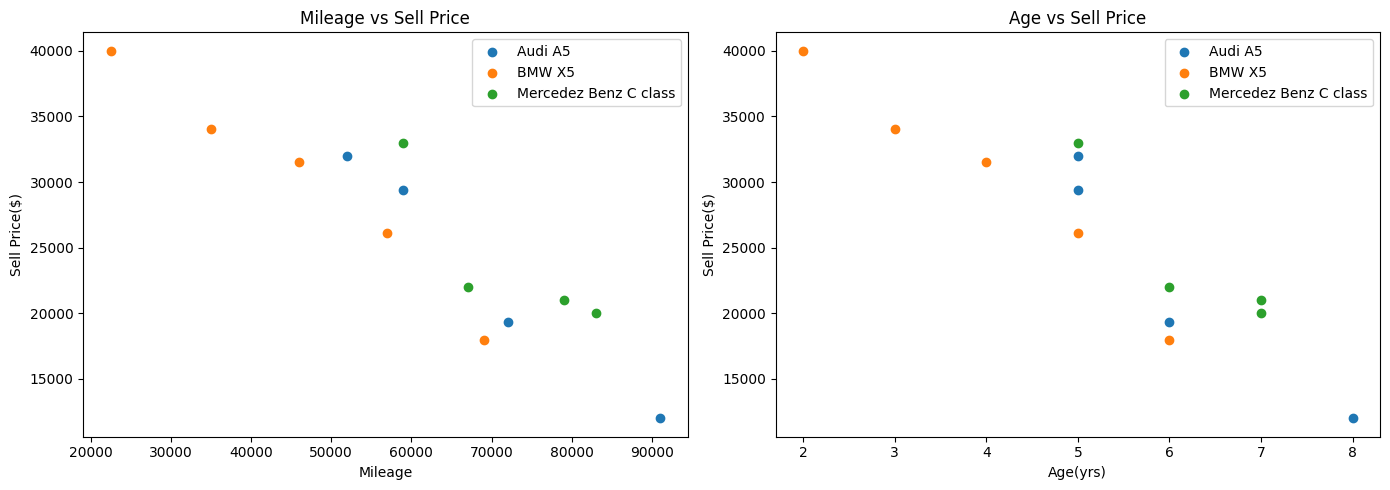

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, group in df.groupby('Car Model'):
    axes[0].scatter(group['Mileage'], group['Sell Price($)'], label=model_name)
    axes[1].scatter(group['Age(yrs)'], group['Sell Price($)'], label=model_name)

axes[0].set_title('Mileage vs Sell Price')
axes[0].set_xlabel('Mileage')
axes[0].set_ylabel('Sell Price($)')

axes[1].set_title('Age vs Sell Price')
axes[1].set_xlabel('Age(yrs)')
axes[1].set_ylabel('Sell Price($)')

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


In [5]:
ct = ColumnTransformer(
    transformers=[('car_model', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['Car Model'])],
    remainder='passthrough'
)

X_encoded = ct.fit_transform(X)
X_encoded


array([[1.00e+00, 0.00e+00, 6.90e+04, 6.00e+00],
       [1.00e+00, 0.00e+00, 3.50e+04, 3.00e+00],
       [1.00e+00, 0.00e+00, 5.70e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 2.25e+04, 2.00e+00],
       [1.00e+00, 0.00e+00, 4.60e+04, 4.00e+00],
       [0.00e+00, 0.00e+00, 5.90e+04, 5.00e+00],
       [0.00e+00, 0.00e+00, 5.20e+04, 5.00e+00],
       [0.00e+00, 0.00e+00, 7.20e+04, 6.00e+00],
       [0.00e+00, 0.00e+00, 9.10e+04, 8.00e+00],
       [0.00e+00, 1.00e+00, 6.70e+04, 6.00e+00],
       [0.00e+00, 1.00e+00, 8.30e+04, 7.00e+00],
       [0.00e+00, 1.00e+00, 7.90e+04, 7.00e+00],
       [0.00e+00, 1.00e+00, 5.90e+04, 5.00e+00]])

In [6]:
model = LinearRegression()
model.fit(X_encoded, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
predict_mercedes = pd.DataFrame([{
    'Car Model': 'Mercedez Benz C class',
    'Mileage': 45000,
    'Age(yrs)': 4
}])

predict_bmw = pd.DataFrame([{
    'Car Model': 'BMW X5',
    'Mileage': 86000,
    'Age(yrs)': 7
}])

mercedes_price = model.predict(ct.transform(predict_mercedes))[0]
bmw_price = model.predict(ct.transform(predict_bmw))[0]

print(f"1) Predicted price of Mercedez Benz C class (4 yrs, 45000 mileage): {mercedes_price:.2f}")
print(f"2) Predicted price of BMW X5 (7 yrs, 86000 mileage): {bmw_price:.2f}")


1) Predicted price of Mercedez Benz C class (4 yrs, 45000 mileage): 36991.32
2) Predicted price of BMW X5 (7 yrs, 86000 mileage): 11080.74


In [8]:
score = model.score(X_encoded, y)
print(f"3) Model score (R^2): {score:.4f}")


3) Model score (R^2): 0.9417
